# MCD8009: Data Discovery - Laboratorio 3

**Integrantes**

| N° | Código | Nombres |  Contribución (0% - 100%) |
|----|--------|---------|---------------------------|
| 1  |        |   CHRISTIAN CAJUSOL MIO |    100%   |


### Indicaciones

- El laboratorio podrá resolverse de manera **individual o en equipos de hasta cuatro (4) personas**. Deberán completar los datos de todos los integrantes, y **una sola persona realizará la entrega del archivo ipynb**.

- Salvo que se indique explícitamente lo contrario, no se prohibe el uso de herramientas de Inteligencia Artificial Generativa, siempre que los integrantes comprendan y puedan explicar el proceso y los resultados obtenidos. **Las respuestas no deben consistir en transcripciones literales de resultados generados por estas herramientas, sino evidenciar comprensión del tema por parte del estudiante o del equipo.**

- En caso de utilizar herramientas de IA Generativa, cada equipo es responsable de verificar la coherencia de las respuestas presentadas. Si se detectan errores, inconsistencias o falta de comprensión, la pregunta podrá ser anulada sin derecho a reclamo.

- En todos los casos, deberá completarse la **Declaración de Uso de IA Generativa.**

- Pueden agregar libremente celdas de código o de Markdown según lo consideren conveniente.

### Declaración de uso de IA Generativa
- Indicar de manera breve la(s) herramienta(s) y/o modelo(s) de IA Generativa utilizados, especificando en qué pregunta(s) se emplearon y con qué propósito.
- En caso no se haya usado, también indicarlo.

**Parte 1:**
- Utilice ChatGPT para investigar con que libreria podria implementar las columnas de Transformación de Box-Cox para averiguar como funciona la libreria( devuelve: los datos transformados, el parámetro lambda óptimo que mejor aproxima la normalidad) y la Transformación de Yeo-Johnson que similarmente devuelve: lambda calculado por Yeo-Johnson.

**Parte2:**
- Utilice ChatGPT para investigar como funciona np.cov y el parámetro: rowvar=False y las operaciones fundamentales matriciales (inversa, multiplicacion matricial, transpuesta)
- Utilice IA para saber como se usan las librerias de: slkearn.ensmeble: IsolationForest, LocalOutlierFactor y DBSCAN

## INICIO DEL LABORATORIO

### Parte 1: Transformaciones (4 puntos)

En clase discutimos la posibilidad de aplicar transformaciones a las variables. Estas transformaciones pueden ayudar a normalizar la distribución y facilitar la detección de valores atípicos, especialmente en datos con colas largas o asimetría. Algunas de las [transformaciones más comunes](https://www.marsja.se/transform-skewed-data-using-square-root-log-box-cox-methods-in-python/) incluyen:

- [Transformación logarítmica](https://medium.com/@kyawsawhtoon/log-transformation-purpose-and-interpretation-9444b4b049c9)
- Transformación de raíz cuadrada
- [Transformación de Box-Cox](https://es.wikipedia.org/wiki/Transformaci%C3%B3n_Box-Cox)
- [Transformación de Yeo-Johnson](https://feature-engine.trainindata.com/en/1.8.x/user_guide/transformation/YeoJohnsonTransformer.html)

| Transformación    | Reduce colas largas | Permite valores negativos | Mejora la normalidad |
|------------------|--------------------|--------------------------|---------------------|
| **Logarítmica**  | ✅ Sí              | ❌ No                    | ✅ Sí               |
| **Raíz cuadrada** | ✅ Moderado       | ❌ No                    | ✅ Parcialmente     |
| **Box-Cox**      | ✅ Automático      | ❌ No                    | ✅ Sí               |
| **Yeo-Johnson**  | ✅ Automático      | ✅ Sí                    | ✅ Sí               |

Una manera práctica (rule-of-thumb) es usar el siguiente criterio:

- Si los datos son sesgados a la derecha: Logarítmica, Box-Cox o raíz cuadrada.
- Si hay valores negativos: Yeo-Johnson o raíz cúbica.
- Si no se sabe qué transformación aplicar: Box-Cox o Yeo-Johnson.

Vamos a continuar con el dataset `Salaries.csv` del laboratorio 2. Nuevamente nuestra variable de interés será "TotalPayBenefits" y vamos a volver considerar los salarios de los empleados en el año 2014 y Status "Full Time" (FT) únicamente. Ejecute estos filtros para el análisis. Agregue 4 columnas al dataset, cada una con su respectiva transformación:

- Logarítmica
- Raíz cuadrada
- Box-Cox
- Yeo-Johnson

Grafique la distribución original + las 4 distribuciones resultantes y comente qué observa. ¿Se ven diferencias entre los 4 métodos? (mire tanto la forma de la distribución resultante como la escala)



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from pathlib import Path
from IPython.display import Image

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from scipy.spatial.distance import mahalanobis
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy.stats import chi2
from sklearn.cluster import DBSCAN
from sklearn.datasets import fetch_openml

In [4]:
salaries = pd.read_csv("Salaries.csv", low_memory=False)
salaries.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


**Filtros solicitados para el análisis**

In [5]:
from sklearn.preprocessing import PowerTransformer   # Para aplicar Yeo-Johnson de forma sencilla
# =========================================================
# INSPECCIÓN BÁSICA DE LAS COLUMNAS RELEVANTES
# =========================================================
# Esto permite verificar que realmente existen las columnas:
# 'Year', 'Status' y 'TotalPayBenefits'
print("\nDimensión ANTES del filtrado:", salaries.shape)
print("\nColumnas del dataset:")
print(salaries.columns.tolist())

# Observa los años disponibles en la columna Year
print("\nValores únicos en Year:")
print(salaries["Year"].dropna().unique())

# Verificamos cuantos tipo de estados exisite en el campo status
print("\nValores únicos en Status:")
print(salaries["Status"].dropna().unique())

# =========================================================
# FILTRADO DEL DATASET
# =========================================================

# Primero, nos aseguramos de que la columna TotalPayBenefits sea numérica.
salaries["TotalPayBenefits"] = pd.to_numeric(salaries["TotalPayBenefits"], errors="coerce")
# Si hubiera valores no numéricos, se convierten en NaN

# Nos quedamos solo con: registros del año 2014 y empleados Full Time (Lo que pide el problema)
df = salaries[(salaries["Year"] == 2014) & (salaries["Status"] == "FT")].copy()

# Muestra cuántas filas quedaron luego del filtro
print("\nDimensión DESPUÉS del filtrado:", df.shape)

# Eliminamos filas con TotalPayBenefits nulo
df = df.dropna(subset=["TotalPayBenefits"]).copy()

print("Dimensión después de eliminar NaN en TotalPayBenefits:", df.shape)

# =========================================================
# INSPECCIÓN DE LA VARIABLE DE INTERÉS
# =========================================================
# Esto ayuda a ver mínimo, máximo, media, percentiles, etc.
print("\nResumen estadístico de TotalPayBenefits:")
print(df["TotalPayBenefits"].describe())

# Este conteo es clave porque segun la tablita del problema, tenemos estas condiciones:
# - logaritmo NO admite valores <= 0
# - raíz cuadrada NO admite valores negativos
# - Box-Cox solo admite valores estrictamente positivos
# - Yeo-Johnson SI admite negativos y cero
print("\nCantidad de valores <= 0 en TotalPayBenefits:", (df["TotalPayBenefits"] <= 0).sum())


Dimensión ANTES del filtrado: (148654, 13)

Columnas del dataset:
['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'TotalPay', 'TotalPayBenefits', 'Year', 'Notes', 'Agency', 'Status']

Valores únicos en Year:
[2011 2012 2013 2014]

Valores únicos en Status:
['PT' 'FT']

Dimensión DESPUÉS del filtrado: (22334, 13)
Dimensión después de eliminar NaN en TotalPayBenefits: (22334, 13)

Resumen estadístico de TotalPayBenefits:
count     22334.000000
mean     138528.412815
std       47879.221966
min       31972.810000
25%      102031.162500
50%      127850.120000
75%      167463.532500
max      479652.210000
Name: TotalPayBenefits, dtype: float64

Cantidad de valores <= 0 en TotalPayBenefits: 0


In [6]:
# =========================================================
# CREACIÓN DE LAS TRANSFORMACIONES
# =========================================================

# ---------- 1. Transformación logarítmica ----------
# Usamos log1p(x) = log(1 + x) para evitar problemas con valores 0
# Si hubiera negativos, esta transformación no sería válida, por eso que validamos
# en la sección anterioer
df["TPB_log"] = np.where(
    df["TotalPayBenefits"] >= 0,
    np.log1p(df["TotalPayBenefits"]),
    np.nan
)
# Si el valor es >= 0, aplica log(1+x)
# Si fuera negativo, coloca NaN


# ---------- 2. Transformación raíz cuadrada ----------
df["TPB_sqrt"] = np.where(
    df["TotalPayBenefits"] >= 0,
    np.sqrt(df["TotalPayBenefits"]),
    np.nan
)
# La raíz cuadrada solo se puede aplicar a valores no negativos
# Si hubiera negativos, coloca NaN


# ---------- 3. Transformación Box-Cox ----------
# Box-Cox requiere valores estrictamente positivos (> 0)
# Por eso tomamos únicamente los positivos.

mask_boxcox = df["TotalPayBenefits"] > 0
# Creamos una máscara booleana para identificar valores válidos para Box-Cox

boxcox_data, lambda_boxcox = stats.boxcox(df.loc[mask_boxcox, "TotalPayBenefits"])
# stats.boxcox devuelve:
# - los datos transformados
# - el parámetro lambda óptimo que mejor aproxima la normalidad

df["TPB_boxcox"] = np.nan
# Inicializamos la columna con NaN para luego rellenar solo donde la transformación es válid

df.loc[mask_boxcox, "TPB_boxcox"] = boxcox_data
# Insertamos los valores transformados en las filas correspondientes

print("\nLambda estimado para Box-Cox:", lambda_boxcox)
# Mostrar lambda es importante porque Box-Cox no es una transformación fija;
# el algoritmo encuentra automáticamente el mejor exponente


# ---------- 4. Transformación Yeo-Johnson ----------
# Yeo-Johnson admite positivos, ceros y negativos.
pt = PowerTransformer(method="yeo-johnson", standardize=False)
# method="yeo-johnson" selecciona la transformación Yeo-Johnson
# standardize=False indica que NO queremos escalar a media 0 y desviación 1;
# solo queremos ver la transformación en sí

df["TPB_yeojohnson"] = pt.fit_transform(df[["TotalPayBenefits"]])
# fit_transform aprende el parámetro lambda óptimo y transforma la variable

lambda_yj = pt.lambdas_[0]
# Recuperamos el lambda calculado por Yeo-Johnson

print("Lambda estimado para Yeo-Johnson:", lambda_yj)

# =========================================================
# VERIFICACIÓN DE LAS NUEVAS COLUMNAS
# =========================================================
  # Verificamos que las 4 nuevas columnas se hayan creado correctamente
print("\nVista previa de las columnas transformadas:")
print(df[["TotalPayBenefits","TPB_log", "TPB_sqrt", "TPB_boxcox", "TPB_yeojohnson"]].head())



Lambda estimado para Box-Cox: -0.32740659725534416
Lambda estimado para Yeo-Johnson: -0.3274168449452087

Vista previa de las columnas transformadas:
        TotalPayBenefits    TPB_log    TPB_sqrt  TPB_boxcox  TPB_yeojohnson
110532         479652.21  13.080819  692.569282    3.012142        3.012054
110534         418019.22  12.943285  646.544059    3.010200        3.010112
110535         417435.10  12.941887  646.092176    3.010180        3.010092
110536         415767.94  12.937885  644.800698    3.010122        3.010034
110537         401070.87  12.901896  633.301563    3.009599        3.009510


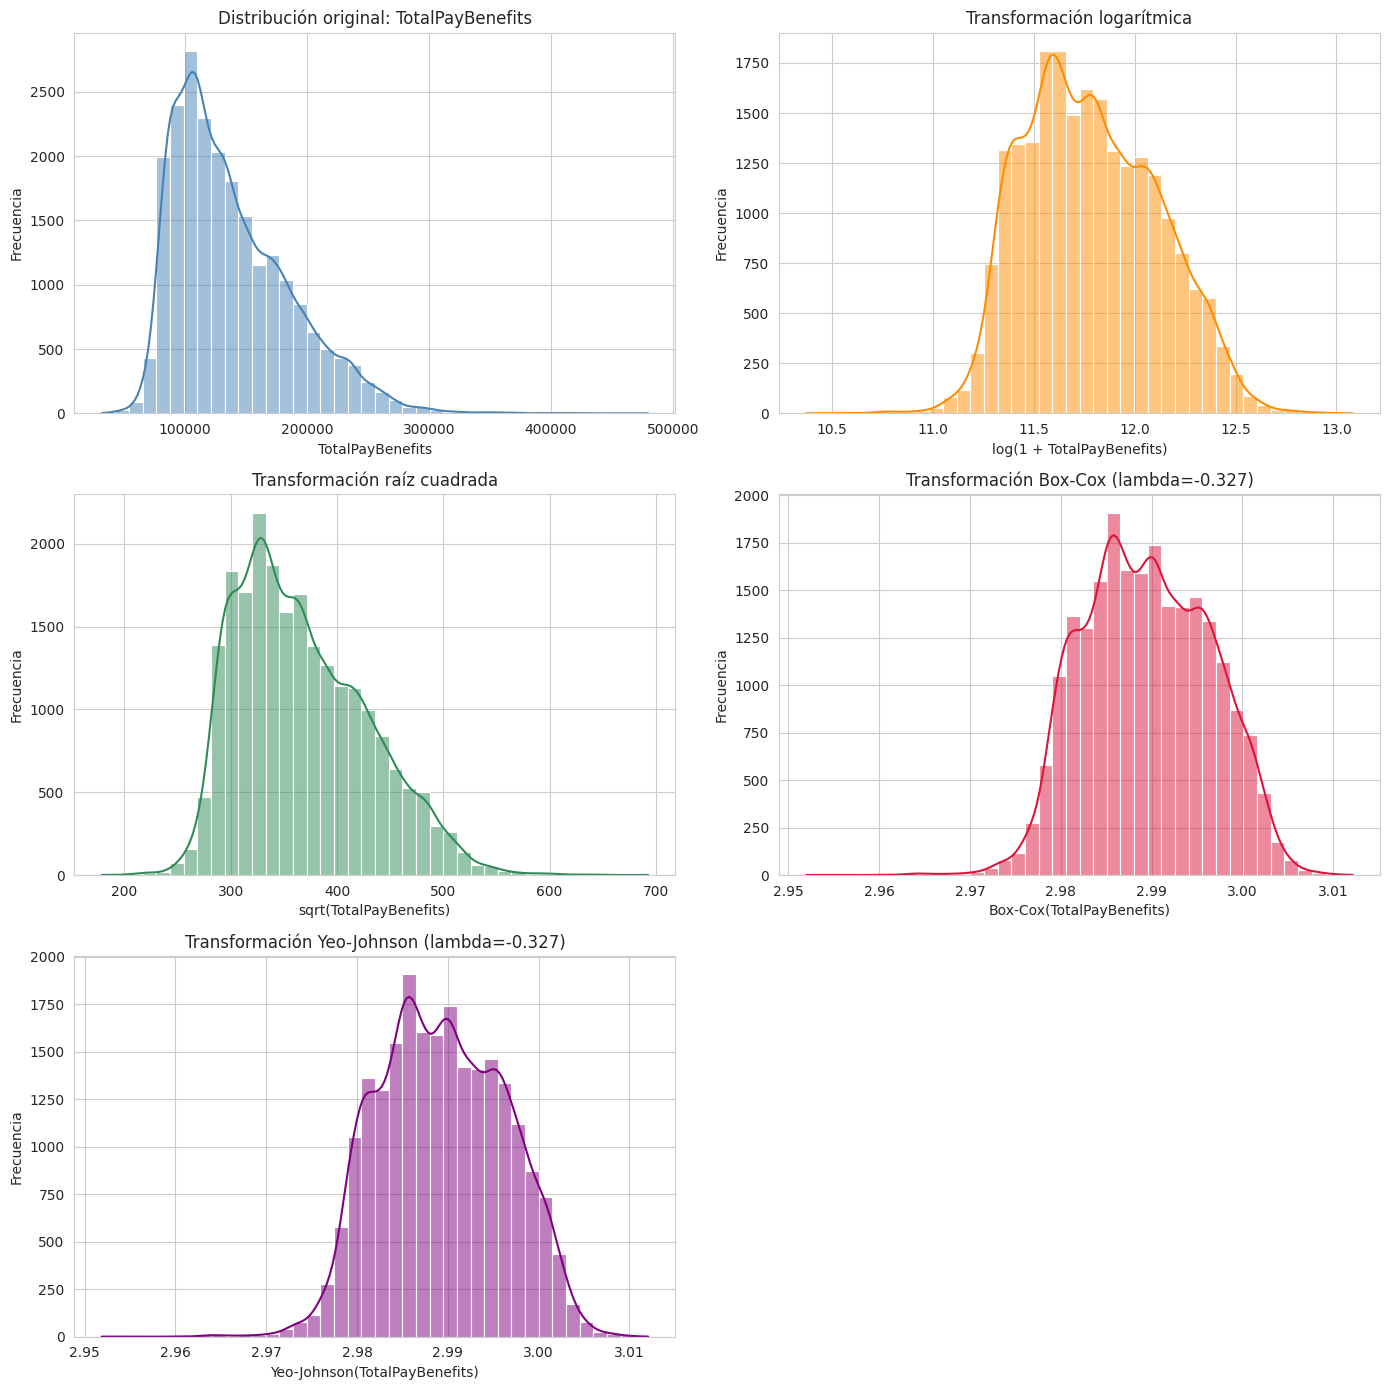


Asimetría (skewness) de cada versión:
Original      : 1.0052748993511191
Logarítmica   : 0.25338379508270864
Raíz cuadrada : 0.6127201503542581
Box-Cox       : 0.01911969479072388
Yeo-Johnson   : 0.019120193673267765


In [7]:
# =========================================================
# GRÁFICOS: DISTRIBUCIÓN ORIGINAL + 4 TRANSFORMACIONES
# =========================================================
# Aplica un estilo visual limpio a los gráficos
sns.set_style("whitegrid")

# Creamos una figura con 6 posiciones:
# usaremos 5 y ocultaremos una
# 3 filas x 2 columnas
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# ----- Gráfico 1: distribución original -----
sns.histplot(df["TotalPayBenefits"], bins=40, kde=True, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_title("Distribución original: TotalPayBenefits")
axes[0, 0].set_xlabel("TotalPayBenefits")
axes[0, 0].set_ylabel("Frecuencia")

# ----- Gráfico 2: logarítmica -----
sns.histplot(df["TPB_log"].dropna(), bins=40, kde=True, color="darkorange", ax=axes[0, 1])
axes[0, 1].set_title("Transformación logarítmica")
axes[0, 1].set_xlabel("log(1 + TotalPayBenefits)")
axes[0, 1].set_ylabel("Frecuencia")

# ----- Gráfico 3: raíz cuadrada -----
sns.histplot(df["TPB_sqrt"].dropna(), bins=40, kde=True, color="seagreen", ax=axes[1, 0])
axes[1, 0].set_title("Transformación raíz cuadrada")
axes[1, 0].set_xlabel("sqrt(TotalPayBenefits)")
axes[1, 0].set_ylabel("Frecuencia")

# ----- Gráfico 4: Box-Cox -----
sns.histplot(df["TPB_boxcox"].dropna(), bins=40, kde=True, color="crimson", ax=axes[1, 1])
axes[1, 1].set_title(f"Transformación Box-Cox (lambda={lambda_boxcox:.3f})")
axes[1, 1].set_xlabel("Box-Cox(TotalPayBenefits)")
axes[1, 1].set_ylabel("Frecuencia")

# ----- Gráfico 5: Yeo-Johnson -----
sns.histplot(df["TPB_yeojohnson"].dropna(), bins=40, kde=True, color="purple", ax=axes[2, 0])
axes[2, 0].set_title(f"Transformación Yeo-Johnson (lambda={lambda_yj:.3f})")
axes[2, 0].set_xlabel("Yeo-Johnson(TotalPayBenefits)")
axes[2, 0].set_ylabel("Frecuencia")

# Ocultamos el sexto subplot vacío
axes[2, 1].axis("off")

# Ajusta automáticamente los espacios entre gráficos
plt.tight_layout()

# Muestra la figura completa
plt.show()

# =========================================================
# MEDIDAS DE ASIMETRÍA PARA COMPARAR OBJETIVAMENTE
# =========================================================

# Mientras más cerca de 0 esté la asimetría, más simétrica es la distribución
print("\nAsimetría (skewness) de cada versión:")
print("Original      :", df["TotalPayBenefits"].skew())
print("Logarítmica   :", df["TPB_log"].dropna().skew())
print("Raíz cuadrada :", df["TPB_sqrt"].dropna().skew())
print("Box-Cox       :", df["TPB_boxcox"].dropna().skew())
print("Yeo-Johnson   :", df["TPB_yeojohnson"].dropna().skew())

**¿Se ven diferencias entre los 4 métodos? (mire tanto la forma de la distribución resultante como la escala)**

Sí, hay diferencias entre los métodos.

En forma:

- La original es claramente sesgada a la derecha.
- La raíz cuadrada mejora un poco la simetría.
- La logarítmica mejora más que la raíz cuadrada.
- Box-Cox y Yeo-Johnson son las que dejan la distribución más cercana a una forma simétrica.

En escala:

- La raíz cuadrada conserva una escala relativamente más cercana a la original.
- La logarítmica comprime bastante más.
- Box-Cox y Yeo-Johnson comprimen todavía más y dejan los datos en intervalos muy pequeños.

**TotalPayBenefits** al inicio tiene un sesgo claro hacia la derecha, porque hay sueldos altos que alargan la cola de la distribución. Después de aplicar las transformaciones, esa asimetría disminuye. La raíz cuadrada la corrige un poco, la logarítmica lo hace mejor, y Box-Cox junto con Yeo-Johnson son las que dejan la distribución más pareja y cercana a una forma normal. También cambia la escala: la raíz cuadrada mantiene valores más cercanos a los originales, mientras que las otras comprimen más los datos. En resumen, sí hay diferencias entre los métodos, tanto en la forma como en la escala.

### Parte 2: Detección de datos atípicos multivariados (10 puntos)

#### 2.1 Parte teórica (5 puntos)

Responda las siguientes preguntas:

a) En el contexto de la maldición de la dimensionalidad, ¿cómo cambia la definición o interpretación de un atípico en espacios de alta dimensión y por qué ciertos métodos de detección de datos atípicos pueden volverse ineficaces? ¿Qué estrategias o enfoques pueden emplearse para mitigar este problema? (2 puntos)

b) En clase revisamos distintos métodos de detección de atípicos multivariantes, pero dicha lista no es extensiva. Otro método conocido, el cual se basada en densidades, es [**LOF (Local Outlier Factor)**](https://en.wikipedia.org/wiki/Local_outlier_factor), que estima el grado de atipicidad de un punto comparando su densidad local con la densidad de sus vecinos más cercanos. A diferencia de enfoques globales, LOF permite identificar outliers locales, es decir, puntos que son anómalos respecto a su vecindario inmediato, incluso si no lo son a nivel global. Se adjunta como hipervínculo su [paper](https://dl.acm.org/doi/epdf/10.1145/335191.335388) y su [implementación en scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html). Vamos a incluir la aplicación de este método en la pregunta 2.2.

Asimismo, existen métodos inspirados en [DBSCAN](https://file.biolab.si/papers/1996-DBSCAN-KDD.pdf) que buscan atacar sus debilidades, estos son:

- **HDBSCAN**, siglas de **H**ierarchical **D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise. Se adjunta como hipervínculo su [paper](https://arxiv.org/pdf/1911.02282).
- **OPTICS**, siglas de **O**rdering **P**oints **T**o **I**dentify the **C**lustering **S**tructure. Se adjunta como hipervínculo su [paper](https://dl.acm.org/doi/epdf/10.1145/304181.304187).

Lea (ya sea a través de los papers o en otras fuentes en internet) y, en sus propias palabras, explique qué mejoran y cómo lo hacen con respecto al DBSCAN original. (3 puntos)

**Respuestas:**

a) En alta dimensión, detectar atípicos se vuelve más difícil porque las distancias entre puntos tienden a parecerse y los datos se vuelven más dispersos, esto hace que la idea de “estar lejos” o “estar en una zona poco densa” pierda fuerza; por eso, los métodos basados en distancia o densidad pueden ser menos efectivos. Para reducir este problema, se puede aplicar reducción de dimensionalidad (PCA), selección de variables (NBEM) o usar métodos diseñados para trabajar en subespacios o estructuras locales.


b) HDBSCAN y OPTICS mejoran a DBSCAN porque manejan mejor datasets con densidades variables. DBSCAN depende de un único valor de eps, lo que limita su desempeño cuando los clusters no tienen la misma densidad. HDBSCAN construye una jerarquía de clusters y elige los más estables, mientras que OPTICS ordena los puntos según su estructura de densidad y permite analizar clusters a diferentes escalas. Por eso, ambos son más flexibles y robustos que DBSCAN.

#### 2.2 Parte práctica (5 puntos)

Vamos a emplear un dataset del sector inmobiliario, en particular, del dataset House Prices de Ames, Iowa, del cual se toman dos variables:

- LotArea: Área total del lote en pies cuadrados.
- GrLivArea: Área habitable sobre el suelo en pies cuadrados.

El objetivo es detectar valores atípicos multivariados en estos datos utilizando los siguientes métodos:

1. **Distancia de Mahalanobis** - α = 0.025
2. **Isolation Forest** - IsolationForest(contamination=0.05, random_state=42)
3. **Local Outlier Factor (LOF)** - LocalOutlierFactor(n_neighbors=20)
4. **DBSCAN** - DBSCAN(eps=350, min_samples=5)

Emplee los argumentos brindados. Realice 4 gráficos de dispersión de las variables LotArea vs GrLivArea (uno por cada método), donde los puntos rojos representen los valores atípicos detectados por cada método y los puntos azules los valores normales. Analice y comente sobre los resultados. ¿Los datos atípicos detectados por estos métodos coinciden con lo que hubieran determinado intuitivamente de manera visual?

In [8]:
data = fetch_openml(name="house_prices", as_frame=True)["data"]
data = data[["LotArea", "GrLivArea"]].dropna().astype(float)
data.head()

,LotArea,GrLivArea
0,8450.0,1710.0
1,9600.0,1262.0
2,11250.0,1786.0
3,9550.0,1717.0
4,14260.0,2198.0


In [9]:
# =========================================================
# IMPORTACIÓN DE LIBRERÍAS
# =========================================================

import numpy as np                           # Para cálculos numéricos y matrices
import pandas as pd                          # Para manejar los datos en DataFrame
import matplotlib.pyplot as plt              # Para hacer gráficos
from scipy.stats import chi2                 # Para obtener el umbral chi-cuadrado en Mahalanobis

from sklearn.ensemble import IsolationForest # Método Isolation Forest
from sklearn.neighbors import LocalOutlierFactor # Método LOF
from sklearn.cluster import DBSCAN           # Método DBSCAN

In [10]:
# =========================================================
# COPIA DEL DATASET
# =========================================================

# Hacemos una copia para no modificar el DataFrame original
df = data.copy()

# Extraemos las dos varibales en formato NumPy
# Esto facilita el uso de los algoritmos de scikit-learn y los cálculos matriciales
X = df[["LotArea", "GrLivArea"]].values

**1. Distancia de Mahalanobis - α = 0.025**

In [11]:
# =========================================================
# 1. DISTANCIA DE MAHALANOBIS
# =========================================================

# Calcula el vector de medias:
# [media de LotArea, media de GrLivArea]
mean_vec = np.mean(X, axis=0)

# Calcula la matriz de covarianza entre las dos variables
# rowvar=False indica que cada columna es una variable
cov_matrix = np.cov(X, rowvar=False)

# Calcula la inversa de la matriz de covarianza
# Esto es necesario para la fórmula de Mahalanobis
cov_inv = np.linalg.inv(cov_matrix)

# Aquí guardaremos las distancias de Mahalanobis al cuadrado
mahal_dist_sq = []

for x in X:
    # Resta cada punto menos el vector media
    diff = x - mean_vec

    # Fórmula de Mahalanobis al cuadrado:
    # (x - mu)' * S^-1 * (x - mu) (Esta en la diapo de Atipicos)
    d2 = diff.T @ cov_inv @ diff

    # Guardamos el resultado para ese punto
    mahal_dist_sq.append(d2)

# Convertimos la lista a arreglo NumPy
mahal_dist_sq = np.array(mahal_dist_sq)

# Nivel de significancia dado por el enunciaddo del probelma
alpha = 0.025

# Umbral crítico de chi-cuadrado con 2 grados de libertad
# porque estamos trabajando con 2 variables
threshold_mahal = chi2.ppf(1 - alpha, df=2)

# Marcamos como True los puntos cuya distancia al cuadrado
# supera el umbral crítico
df["outlier_mahal"] = mahal_dist_sq > threshold_mahal

print("Atípicos detectados por Mahalanobis:", df["outlier_mahal"].sum())
print("Umbral chi-cuadrado (Mahalanobis):", threshold_mahal)


Atípicos detectados por Mahalanobis: 33
Umbral chi-cuadrado (Mahalanobis): 7.377758908227871


**2. Isolation Forest - IsolationForest(contamination=0.05, random_state=42)**

In [12]:
# =========================================================
# 2. ISOLATION FOREST
# =========================================================

# Creamos el modelo exactamente con los parámetros pedidos
iso = IsolationForest(contamination=0.05, random_state=42)

# Entrenamos el modelo y obtenemos etiquetas
# Devuelve:
#  1  = normal
# -1  = atípico
iso_pred = iso.fit_predict(X)

# Convertimos la salida a booleanos:
# True si es atípico
df["outlier_iforest"] = iso_pred == -1


print("Atípicos detectados por Isolation Forest:", df["outlier_iforest"].sum())

Atípicos detectados por Isolation Forest: 73


**3. Local Outlier Factor (LOF) - LocalOutlierFactor(n_neighbors=20)**

In [13]:
# =========================================================
# 3. LOCAL OUTLIER FACTOR (LOF)
# =========================================================

lof = LocalOutlierFactor(n_neighbors=20)
# Creamos el modelo LOF con el argumento dado en el enunciado

lof_pred = lof.fit_predict(X)
# Ajustamos el modelo y obtenemos las etiquetas:
#  1  = normal
# -1  = atípico

df["outlier_lof"] = lof_pred == -1
# Guardamos como True los atípicos detectados

print("Atípicos detectados por LOF:", df["outlier_lof"].sum())


Atípicos detectados por LOF: 43


**4. DBSCAN - DBSCAN(eps=350, min_samples=5)**

In [14]:
# =========================================================
# 4. DBSCAN
# =========================================================

dbscan = DBSCAN(eps=350, min_samples=5)
# Creamos DBSCAN con los valores exactos pedidos

db_labels = dbscan.fit_predict(X)
# Ajustamos el modelo y obtenemos etiquetas:
# -1 = ruido / atípico
#  0,1,2,... = clusters

df["outlier_dbscan"] = db_labels == -1
# Marcamos como True los puntos etiquetados como ruido

print("Atípicos detectados por DBSCAN:", df["outlier_dbscan"].sum())


Atípicos detectados por DBSCAN: 87


**Graficos**

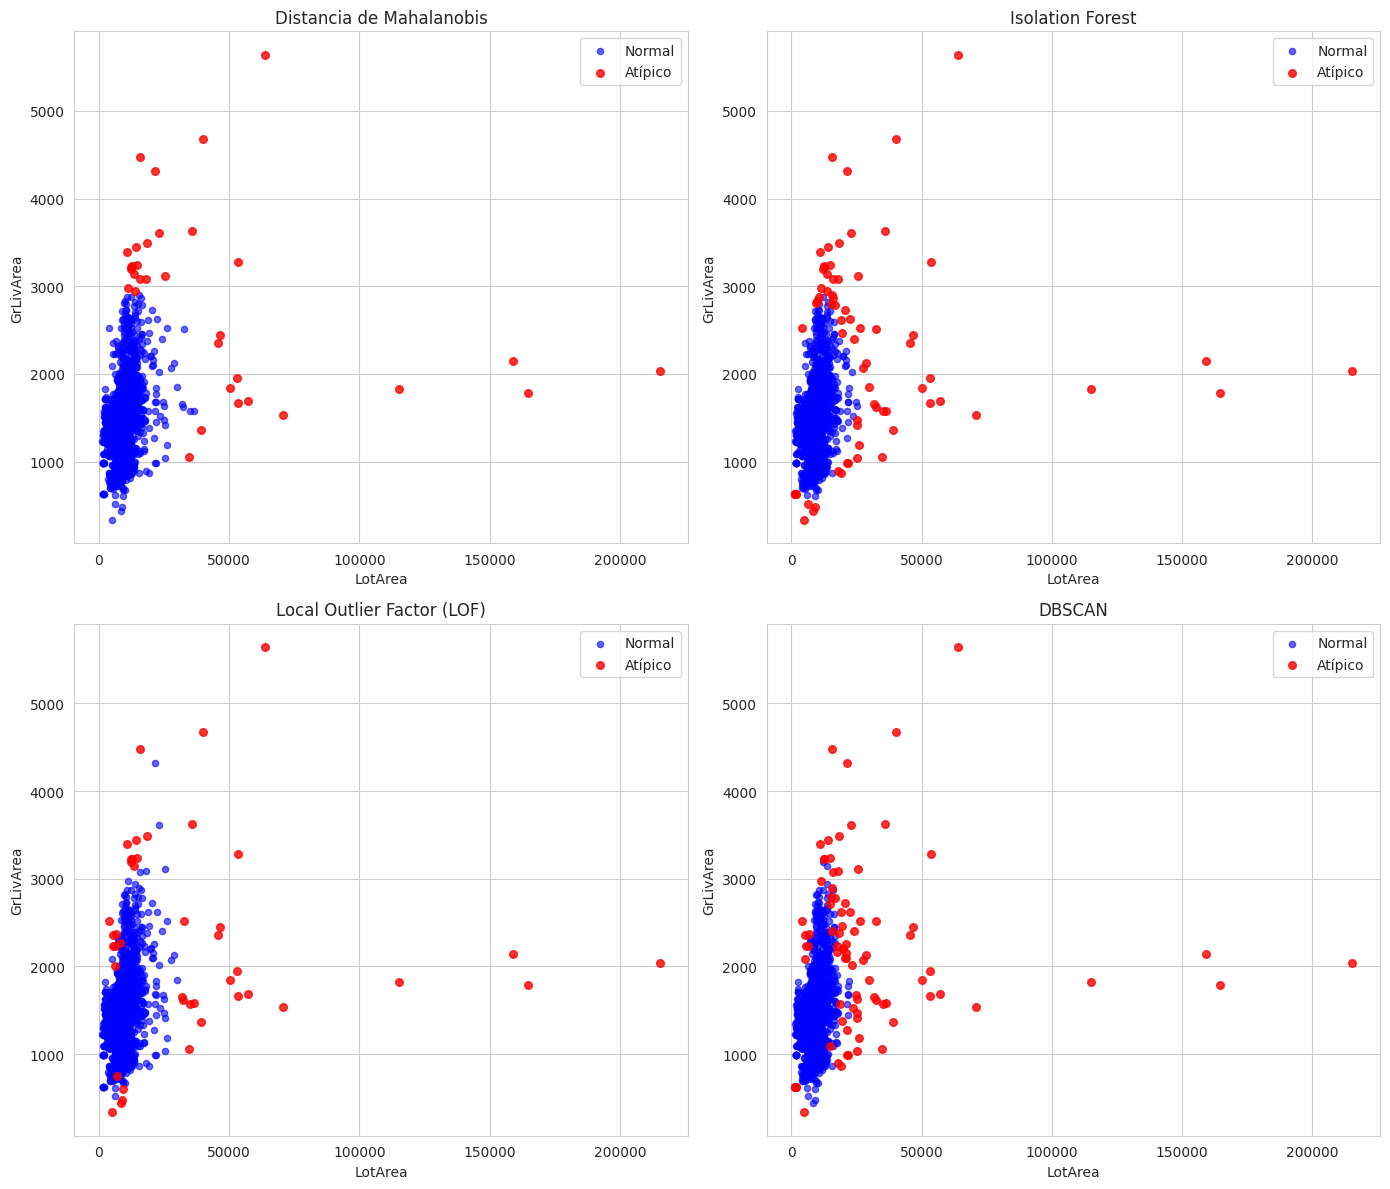

             Método  N° de atípicos
0       Mahalanobis              33
1  Isolation Forest              73
2               LOF              43
3            DBSCAN              87


In [15]:
# =========================================================
# GRÁFICOS DE DISPERSIÓN
# =========================================================
# Creamos una figura con 4 subgráficos: 2 filas x 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# -------------------------
# Gráfico 1: Mahalanobis
# -------------------------

axes[0, 0].scatter(
    df.loc[~df["outlier_mahal"], "LotArea"],     # X de puntos normales
    df.loc[~df["outlier_mahal"], "GrLivArea"],   # Y de puntos normales
    c="blue",
    s=20,
    alpha=0.6,
    label="Normal"
)

axes[0, 0].scatter(
    df.loc[df["outlier_mahal"], "LotArea"],      # X de puntos atípicos
    df.loc[df["outlier_mahal"], "GrLivArea"],    # Y de puntos atípicos
    c="red",
    s=30,
    alpha=0.8,
    label="Atípico"
)

axes[0, 0].set_title("Distancia de Mahalanobis")
axes[0, 0].set_xlabel("LotArea")
axes[0, 0].set_ylabel("GrLivArea")
axes[0, 0].legend()


# -------------------------
# Gráfico 2: Isolation Forest
# -------------------------

axes[0, 1].scatter(
    df.loc[~df["outlier_iforest"], "LotArea"],
    df.loc[~df["outlier_iforest"], "GrLivArea"],
    c="blue",
    s=20,
    alpha=0.6,
    label="Normal"
)

axes[0, 1].scatter(
    df.loc[df["outlier_iforest"], "LotArea"],
    df.loc[df["outlier_iforest"], "GrLivArea"],
    c="red",
    s=30,
    alpha=0.8,
    label="Atípico"
)

axes[0, 1].set_title("Isolation Forest")
axes[0, 1].set_xlabel("LotArea")
axes[0, 1].set_ylabel("GrLivArea")
axes[0, 1].legend()


# -------------------------
# Gráfico 3: LOF
# -------------------------

axes[1, 0].scatter(
    df.loc[~df["outlier_lof"], "LotArea"],
    df.loc[~df["outlier_lof"], "GrLivArea"],
    c="blue",
    s=20,
    alpha=0.6,
    label="Normal"
)

axes[1, 0].scatter(
    df.loc[df["outlier_lof"], "LotArea"],
    df.loc[df["outlier_lof"], "GrLivArea"],
    c="red",
    s=30,
    alpha=0.8,
    label="Atípico"
)

axes[1, 0].set_title("Local Outlier Factor (LOF)")
axes[1, 0].set_xlabel("LotArea")
axes[1, 0].set_ylabel("GrLivArea")
axes[1, 0].legend()


# -------------------------
# Gráfico 4: DBSCAN
# -------------------------

axes[1, 1].scatter(
    df.loc[~df["outlier_dbscan"], "LotArea"],
    df.loc[~df["outlier_dbscan"], "GrLivArea"],
    c="blue",
    s=20,
    alpha=0.6,
    label="Normal"
)

axes[1, 1].scatter(
    df.loc[df["outlier_dbscan"], "LotArea"],
    df.loc[df["outlier_dbscan"], "GrLivArea"],
    c="red",
    s=30,
    alpha=0.8,
    label="Atípico"
)

axes[1, 1].set_title("DBSCAN")
axes[1, 1].set_xlabel("LotArea")
axes[1, 1].set_ylabel("GrLivArea")
axes[1, 1].legend()

# Ajusta automáticamente los espacios entre gráficos
plt.tight_layout()

# Muestro los 4 gráficos
plt.show()



# =========================================================
# TABLA RESUMEN
# =========================================================

resumen = pd.DataFrame({
    "Método": ["Mahalanobis", "Isolation Forest", "LOF", "DBSCAN"],
    "N° de atípicos": [
        df["outlier_mahal"].sum(),
        df["outlier_iforest"].sum(),
        df["outlier_lof"].sum(),
        df["outlier_dbscan"].sum()
    ]
})

print(resumen)
# Mostramos cuántos atípicos detectó cada método.

### Parte 3: Calidad de datos (6 puntos)

Se presenta un dataset que contiene 200 solicitudes de crédito personal. Asimismo, se proporciona un diccionario de datos, en el cual se especifica para cada variable: el nombre de la columna, el tipo de dato, su descripción, si admite valores nulos y si posee alguna restricción.

El objetivo de este ejercicio es implementar las 10 reglas de calidad de datos indicadas en la tabla. Cabe señalar que, en base al diccionario de datos, podrían definirse muchas más reglas; sin embargo, para efectos de esta actividad, solo se deben considerar las 10 especificadas.

Como resultado final, se espera una tabla o un reporte (prints) que incluya:

- La cantidad y % de registros que incumplen cada regla de calidad.
- El id_solicitud y los valores correspondientes a los registros que presentan incumplimientos.

La implementación puede realizarse utilizando `Great Expectations` o mediante validaciones ad-hoc en código.

#### Diccionario de datos

| # | Columna | Tipo | Descripción | Ejemplo | Nulos permitidos | Restricción / Dominio |
|---|---------|------|-------------|---------|------------------|-----------------------|
| 1 | `id_solicitud` | str | Identificador único de la solicitud | `SOL-00001` | No | Formato `SOL-NNNNN` |
| 2 | `dni` | str | DNI del solicitante (Perú) | `12345678` | No | Exactamente 8 dígitos numéricos |
| 3 | `nombre` | str | Nombre completo del solicitante | `Ana García López` | No | Texto libre, no vacío |
| 4 | `fecha_nacimiento` | date | Fecha de nacimiento | `1990-03-15` | No | Fecha válida; coherente con `edad` |
| 5 | `edad` | int | Edad declarada (años) | `34` | No | Entre 18 y 80 inclusive |
| 6 | `email` | str | Correo electrónico de contacto | `ana@gmail.com` | No | Formato RFC estándar |
| 7 | `telefono` | str | Teléfono celular (Perú) | `987654321` | No | 9 dígitos, inicia en `9` |
| 8 | `ingreso_mensual` | float | Ingreso neto mensual declarado (S/) | `3500.00` | No | > 0 |
| 9 | `monto_solicitado` | float | Monto del crédito solicitado (S/) | `15000.00` | No | > 0 |
| 10 | `plazo_meses` | int | Plazo del crédito en meses | `36` | No | Uno de: {12, 24, 36, 48, 60} |
| 11 | `cuota_mensual` | float | Cuota mensual del crédito (S/) | `512.50` | No | > 0; ≤ 30 % del `ingreso_mensual` |
| 12 | `tipo_empleo` | str | Situación laboral del solicitante | `dependiente` | No | {`dependiente`, `independiente`, `desempleado`} |
| 13 | `empresa` | str | Nombre del empleador | `Empresa_SAC_012` | Sí (si no es dependiente) | Obligatorio cuando `tipo_empleo = dependiente` |
| 14 | `estado_solicitud` | str | Estado actual del trámite | `aprobada` | No | {`aprobada`, `rechazada`, `en_revision`} |
| 15 | `fecha_solicitud` | date | Fecha en que se registró la solicitud | `2024-03-20` | No | Fecha válida |
| 16 | `fecha_resolucion` | date | Fecha en que se resolvió la solicitud | `2024-03-28` | Sí (si aún en revisión) | Cuando existe: ≥ `fecha_solicitud` |

#### Reglas de calidad a implementar

| ID | Columna(s) | Descripción |
|----|-----------|-------------|
| **R1** | `dni` | El DNI peruano tiene exactamente 8 dígitos numéricos |
| **R2** | `email` | Estructura `usuario@dominio.ext` |
| **R3** | `telefono` |  Celular peruano: 9 dígitos, inicia en `9` |
| **R4** | `edad` | Menores de 18 no pueden contratar; política de riesgo limita a 80 |
| **R5** | `ingreso_mensual` | Un ingreso ≤ 0 es imposible para calificar al crédito |
| **R6** | `tipo_empleo` | Solo se aceptan tres valores codificados en el sistema |
| **R7** | `tipo_empleo` + `empresa`  | Si es `dependiente`, debe declarar obligatoriamente su empleador |
| **R8** | `fecha_solicitud` + `fecha_resolucion`  | Una solicitud no puede resolverse antes de haberse registrado |
| **R9** | `edad` + `fecha_nacimiento`  | La edad declarada debe ser coherente con la fecha de nacimiento (±1 año) |
| **R10** | `cuota_mensual` + `ingreso_mensual`  | La cuota no puede superar el 30 % del ingreso neto (Reglamento SBS Perú) |

In [16]:
df_creditos=pd.read_csv("solicitudes_credito.csv", parse_dates=["fecha_nacimiento", "fecha_solicitud", "fecha_resolucion"])
df_creditos.head()

,id_solicitud,dni,nombre,fecha_nacimiento,edad,email,telefono,ingreso_mensual,monto_solicitado,plazo_meses,cuota_mensual,tipo_empleo,empresa,estado_solicitud,fecha_solicitud,fecha_resolucion
0,SOL-00001,95822412,Sofía Rivera Pérez,1965-01-01,60,usuario0@yahoo.com,953389073,3306.20,7047.62,48,207.02,dependiente,Empresa_EIRL_000,aprobada,2024-08-25,2024-08-28
1,SOL-00002,24942603,Jorge Torres Ramírez,1975-01-02,50,usuario1@gmail.com,925558733,2670.08,18637.76,36,673.80,dependiente,Empresa_SA_001,aprobada,2024-10-15,2024-10-23
2,SOL-00003,13356886,Luis Martínez Martínez,1989-01-01,36,usuario2@outlook.com,964247457,5051.93,22101.36,24,1103.39,dependiente,Empresa_EIRL_002,en_revision,2024-10-23,2024-11-21
3,SOL-00004,46913810,Luis Pérez García,1961-01-01,64,usuario3@outlook.com,979067939,2755.68,5645.25,60,143.35,dependiente,Empresa_SAC_003,aprobada,2024-08-17,2024-08-18
4,SOL-00005,42868828,Miguel Torres Martínez,1996-01-02,29,usuario4@gmail.com,910154493,4273.86,30730.78,60,780.36,dependiente,Empresa_SA_004,en_revision,2024-12-14,2024-12-27


In [18]:
# Hacemos una copia para no modificar el DataFrame original
df = df_creditos.copy()

# Muestra cuántas filas y columnas tiene el dataset
print("Dimensión del dataset:", df.shape)

# =========================================================
# NORMALIZACIÓN BÁSICA DE COLUMNAS DE TEXTO
# =========================================================

# Convertimos algunas columnas a string y quitamos espacios externos
cols_texto = [
    "id_solicitud", "dni", "nombre", "email", "telefono",
    "tipo_empleo", "empresa", "estado_solicitud"
]

for col in cols_texto:
    # Esto ayuda a evitar errores por espacios al inicio o al final de cada string
    df[col] = df[col].astype("string").str.strip()

# Pasamos tipo_empleo a minúsculas para validar dominios con consistencia
df["tipo_empleo"] = df["tipo_empleo"].str.lower()

# =========================================================
# FECHA DE REFERENCIA PARA VALIDAR EDAD
# =========================================================

# Para contrastar edad con fecha_nacimiento, usaremos como referncia
# la fecha_solicitud, porque la edad declarada tiene sentido al momento
# en que la persona hace la solicitud
fecha_ref = df["fecha_solicitud"]


# =========================================================
# CÁLCULO DE EDAD ESPERADA A PARTIR DE FECHA_NACIMIENTO
# =========================================================

# Diferencia inicial entre años.
edad_calculada = fecha_ref.dt.year - df["fecha_nacimiento"].dt.year

# Determina si ya cumplió años en la fecha de solicitud
cumplio_anios = (
    (fecha_ref.dt.month > df["fecha_nacimiento"].dt.month) |
    (
        (fecha_ref.dt.month == df["fecha_nacimiento"].dt.month) &
        (fecha_ref.dt.day >= df["fecha_nacimiento"].dt.day)
    )
)

# Si aún no había cumplido años en la fecha de solicitud, restamos 1
edad_calculada = edad_calculada - (~cumplio_anios).astype(int)

# =========================================================
# REGLAS DE CALIDAD (TRUE = INCUMPLE) POR ESO NEGARE CON NARGIN LA MAYORIA DE
# LOS FLITROS POR ESTRATEGIA
# =========================================================

# -------------------------
# R1: dni -> exactamente 8 dígitos numéricos
# -------------------------
# fullmatch exige que toda la cadena sean exactamente 8 dígitos
# El ~ invierte el resultado:
# True = incumple
df["R1"] = ~df["dni"].str.fullmatch(r"\d{8}", na=False)

# -------------------------
# R2: email -> estructura usuario@dominio.ext
# -------------------------
# Valida una estructura razonable de email
# No pretende cubrir todos los casos posibles del estándar RFC,
# pero sí una validación práctica para calidad de datos

df["R2"] = ~df["email"].str.fullmatch(
    r"[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}",
    na=False
)

# -------------------------
# R3: telefono -> 9 dígitos e inicia en 9
# -------------------------
# Deb comenzar con 9 y luego tener 8 dígitos más
df["R3"] = ~df["telefono"].str.fullmatch(r"9\d{8}", na=False)

# -------------------------
# R4: edad -> entre 18 y 80 inclusive
# -------------------------
# Marca como incumplimiento si la edad está fuera del rango permitido INVLUYE LOS EXTREMOS
df["R4"] = ~df["edad"].between(18, 80, inclusive="both")

# -------------------------
# R5: ingreso_mensual -> debe ser > 0
# -------------------------
# Si ingreso_mensual no es mayor que 0, incumple
df["R5"] = ~(df["ingreso_mensual"] > 0)

# -------------------------
# R6: tipo_empleo -> uno de {dependiente, independiente, desempleado}
# -------------------------
# Marca como incumplimiento si tipo_empleo no está dentro del dominio permitido
valores_tipo_empleo = {"dependiente", "independiente", "desempleado"}
df["R6"] = ~df["tipo_empleo"].isin(valores_tipo_empleo)

# -------------------------
# R7: tipo_empleo + empresa
# Si tipo_empleo = dependiente, empresa es obligatoria
# -------------------------
# Define cuándo empresa está vacía o nula
empresa_vacia = df["empresa"].isna() | (df["empresa"].str.strip() == "")

# Incumple solo si es dependiente y no declaró empresa
df["R7"] = (df["tipo_empleo"] == "dependiente") & empresa_vacia

# -------------------------
# R8: fecha_solicitud + fecha_resolucion
# Si fecha_resolucion existe, debe ser >= fecha_solicitud
# -------------------------
# Incumple si la resolución ocurrió antes de la solicitud
df["R8"] = (
    df["fecha_resolucion"].notna() &
    (df["fecha_resolucion"] < df["fecha_solicitud"])
)

# -------------------------
# R9: edad + fecha_nacimiento
# Edad declarada coherente con fecha_nacimiento (±1 año)
# -------------------------
# Si la diferencia absoluta supera 1 año, se considera inconsistente.
df["R9"] = (df["edad"] - edad_calculada).abs() > 1

# -------------------------
# R10: cuota_mensual + ingreso_mensual
# cuota_mensual <= 30 % del ingreso neto
# -------------------------
# Incumple si la cuota supera el 30% del ingreso mensual.
df["R10"] = df["cuota_mensual"] > (0.30 * df["ingreso_mensual"])



# =========================================================
# TABLA RESUMEN DE INCUMPLIMIENTOS
# =========================================================

reglas_info = {
    "R1": "DNI con exactamente 8 dígitos",
    "R2": "Email con estructura usuario@dominio.ext",
    "R3": "Teléfono celular peruano válido",
    "R4": "Edad entre 18 y 80",
    "R5": "Ingreso mensual mayor que 0",
    "R6": "Tipo de empleo dentro del dominio permitido",
    "R7": "Empresa obligatoria si tipo_empleo = dependiente",
    "R8": "Fecha de resolución no anterior a la solicitud",
    "R9": "Edad coherente con fecha de nacimiento (±1 año)",
    "R10": "Cuota mensual no supera 30% del ingreso"
}
# Diccionario para etiquetar mejor las reglas.

resumen = []

n = len(df)
# Número total de registros.

for regla, descripcion in reglas_info.items():
    cant_incumplen = df[regla].sum()
    # Como True = incumple, sum() cuenta los incumplimientos

    pct_incumplen = (cant_incumplen / n) * 100
    # Calcula el porcentaje respecto al total

    resumen.append({
        "Regla": regla,
        "Descripción": descripcion,
        "Cantidad_incumplen": cant_incumplen,
        "Porcentaje_incumplen": str(round(pct_incumplen, 2)) +'%'
    })

resumen_df = pd.DataFrame(resumen)
# Convertimos la lista de diccionarios en DataFrame

print("\n================TABLA RESUMEN DE CALIDAD DE DATOS ================\n")
print(resumen_df)
# Muestra la tabla resumn


# =========================================================
# DETALLE DE REGISTROS INCUMPLIDOS POR REGLA
# =========================================================

print("\n================ DETALLE DE INCUMPLIMIENTOS ================\n")

# R1
print("\n--- R1: DNI inválido ---")
print(df.loc[df["R1"], ["id_solicitud", "dni"]])

# R2
print("\n--- R2: Email inválido ---")
print(df.loc[df["R2"], ["id_solicitud", "email"]])

# R3
print("\n--- R3: Teléfono inválido ---")
print(df.loc[df["R3"], ["id_solicitud", "telefono"]])

# R4
print("\n--- R4: Edad fuera de rango ---")
print(df.loc[df["R4"], ["id_solicitud", "edad"]])

# R5
print("\n--- R5: Ingreso mensual inválido ---")
print(df.loc[df["R5"], ["id_solicitud", "ingreso_mensual"]])

# R6
print("\n--- R6: Tipo de empleo inválido ---")
print(df.loc[df["R6"], ["id_solicitud", "tipo_empleo"]])

# R7
print("\n--- R7: Empresa faltante para dependiente ---")
print(df.loc[df["R7"], ["id_solicitud", "tipo_empleo", "empresa"]])

# R8
print("\n--- R8: Fecha de resolución anterior a fecha de solicitud ---")
print(df.loc[df["R8"], ["id_solicitud", "fecha_solicitud", "fecha_resolucion"]])

# R9
print("\n--- R9: Edad inconsistente con fecha de nacimiento ---")
print(df.loc[df["R9"], ["id_solicitud", "fecha_nacimiento", "fecha_solicitud", "edad"]])

# R10
print("\n--- R10: Cuota mensual supera el 30% del ingreso ---")
print(df.loc[df["R10"], ["id_solicitud", "ingreso_mensual", "cuota_mensual"]])

Dimensión del dataset: (200, 16)

================TABLA RESUMEN DE CALIDAD DE DATOS ================

  Regla                                       Descripción  Cantidad_incumplen  \
0    R1                     DNI con exactamente 8 dígitos                   5   
1    R2          Email con estructura usuario@dominio.ext                   4   
2    R3                   Teléfono celular peruano válido                   3   
3    R4                                Edad entre 18 y 80                   3   
4    R5                       Ingreso mensual mayor que 0                   2   
5    R6       Tipo de empleo dentro del dominio permitido                   2   
6    R7  Empresa obligatoria si tipo_empleo = dependiente                   1   
7    R8    Fecha de resolución no anterior a la solicitud                   3   
8    R9   Edad coherente con fecha de nacimiento (±1 año)                   3   
9   R10           Cuota mensual no supera 30% del ingreso                  50   

  Porc